In [1]:
import os


In [2]:
os.getcwd()

'c:\\Users\\user\\Desktop\\PYTHON BASICS\\DataCamp\\Pyspark'

In [3]:
from pyspark.sql import SparkSession

In [66]:
from pyspark.sql.functions import col

In [4]:
spark = SparkSession.builder.master('local').getOrCreate()

In [10]:
df = spark.read.csv(r'C:\Users\user\Desktop\PYTHON BASICS\DataCamp\clean_data.csv', header=True)

In [11]:
df.describe()

DataFrame[summary: string, Store_ID: string, Month: string, Dept: string, IsHoliday: string, Weekly_Sales: string, CPI: string, Unemployment: string]

In [12]:
df.show(3)

+--------+-----+----+---------+------------+-----------+------------+
|Store_ID|Month|Dept|IsHoliday|Weekly_Sales|        CPI|Unemployment|
+--------+-----+----+---------+------------+-----------+------------+
|       1|    2|   1|        0|     24924.5|211.0963582|       8.106|
|       1|    2|  26|        0|    11737.12|211.0963582|       8.106|
|       1|    2|  17|        0|    13223.76|211.0963582|       8.106|
+--------+-----+----+---------+------------+-----------+------------+
only showing top 3 rows



In [13]:
df.select('Month', 'Dept')

DataFrame[Month: string, Dept: string]

In [14]:
df.count()

106168

In [19]:
df.select('Store_ID').show(5)

+--------+
|Store_ID|
+--------+
|       1|
|       1|
|       1|
|       1|
|       1|
+--------+
only showing top 5 rows



In [50]:
salesover = df.filter(df['Weekly_Sales'] > 100000 )

In [53]:
storecat = salesover.groupby('Store_ID').count()

In [61]:
storecat.orderBy('Store_ID').show(17)

+--------+-----+
|Store_ID|count|
+--------+-----+
|       1|  299|
|      10|  401|
|      11|   20|
|      12|   10|
|      13|  476|
|      14|  587|
|      15|    5|
|      16|    4|
|      17|    8|
|      18|   18|
|      19|  206|
|       2|  369|
|      20|  517|
|      21|    6|
|      22|   14|
|      23|   44|
|      24|   84|
+--------+-----+
only showing top 17 rows



In [62]:
df_Department = df.withColumnRenamed('Dept', 'Department')

df_Department.show(10)

+--------+-----+----------+---------+------------+-----------+------------+
|Store_ID|Month|Department|IsHoliday|Weekly_Sales|        CPI|Unemployment|
+--------+-----+----------+---------+------------+-----------+------------+
|       1|    2|         1|        0|     24924.5|211.0963582|       8.106|
|       1|    2|        26|        0|    11737.12|211.0963582|       8.106|
|       1|    2|        17|        0|    13223.76|211.0963582|       8.106|
|       1|    2|        79|        0|    46729.77|211.0963582|         0.0|
|       1|    2|        55|        0|    21249.31|211.0963582|         0.0|
|       1|    2|         5|        0|    32229.38|211.0963582|         0.0|
|       1|    2|        95|        0|   106690.06|211.0963582|       8.106|
|       1|    2|         2|        0|    50605.27|211.0963582|       8.106|
|       1|    2|         4|        0|    39954.04|211.0963582|       8.106|
|       1|    2|        80|        0|    15694.17|211.0963582|       8.106|
+--------+--

In [63]:
df_Department.printSchema()

root
 |-- Store_ID: string (nullable = true)
 |-- Month: string (nullable = true)
 |-- Department: string (nullable = true)
 |-- IsHoliday: string (nullable = true)
 |-- Weekly_Sales: string (nullable = true)
 |-- CPI: string (nullable = true)
 |-- Unemployment: string (nullable = true)



In [64]:
df.describe()

DataFrame[summary: string, Store_ID: string, Month: string, Dept: string, IsHoliday: string, Weekly_Sales: string, CPI: string, Unemployment: string]

In [67]:
df = df.withColumn("Weekly_Sales", col("Weekly_Sales").cast("int"))

In [68]:
df.describe()

DataFrame[summary: string, Store_ID: string, Month: string, Dept: string, IsHoliday: string, Weekly_Sales: string, CPI: string, Unemployment: string]

In [69]:
df_Department.printSchema()

root
 |-- Store_ID: string (nullable = true)
 |-- Month: string (nullable = true)
 |-- Department: string (nullable = true)
 |-- IsHoliday: string (nullable = true)
 |-- Weekly_Sales: string (nullable = true)
 |-- CPI: string (nullable = true)
 |-- Unemployment: string (nullable = true)



In [70]:
sales2 = df.filter(df.Weekly_Sales > 100000 )

In [71]:
sales2.count()

3672

In [72]:
salesover.count()

3672

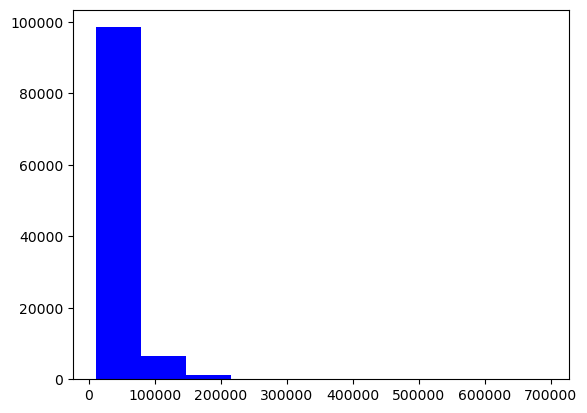

In [78]:
import matplotlib.pyplot as plt

# Convert Spark DataFrame to Pandas
df_his = df.select('Weekly_Sales').toPandas()

# Plot histogram
plt.hist(df_his['Weekly_Sales'], bins=10, color='blue')

# Show plot
plt.show()

In [ ]:
# Check the column names of names_df
print("The column names of names_df are", names_df.columns)

# Convert to Pandas DataFrame  
df_pandas = names_df.toPandas()

# Create a horizontal bar plot
df_pandas.plot(kind='barh', x='Name', y='Age', colormap='winter_r')

plt.show()